In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

In [2]:
age = [25, 32, 47, 51, 29, 36]
annual_income = [12, 18, 45, 60, 15, 30]
gender = ['男', '女', '男', '女', '女', '男']

In [4]:
X_num = np.array(list(zip(age, annual_income)))
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_num_scaled

array([[-1.24210352, -1.03407298],
       [-0.49684141, -0.68938199],
       [ 1.10014883,  0.86172748],
       [ 1.5260129 ,  1.72345497],
       [-0.81623946, -0.86172748],
       [-0.07097734,  0.        ]])

In [5]:
encoder = OneHotEncoder(sparse_output=False)
X_cat = np.array(gender).reshape(-1, 1)
X_cat_encoded = encoder.fit_transform(X_cat)
X_cat_encoded

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.]])

In [6]:
X_combined = np.hstack([X_num_scaled, X_cat_encoded])
X_combined

array([[-1.24210352, -1.03407298,  0.        ,  1.        ],
       [-0.49684141, -0.68938199,  1.        ,  0.        ],
       [ 1.10014883,  0.86172748,  0.        ,  1.        ],
       [ 1.5260129 ,  1.72345497,  1.        ,  0.        ],
       [-0.81623946, -0.86172748,  1.        ,  0.        ],
       [-0.07097734,  0.        ,  0.        ,  1.        ]])

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)
print("PCA降维后的数据（2个主成分）：")
print(X_pca)
print("各主成分解释方差比例：", pca.explained_variance_ratio_)
print("累计解释方差比例：", np.cumsum(pca.explained_variance_ratio_))

PCA降维后的数据（2个主成分）：
[[-1.63852071 -0.63902895]
 [-0.80748924  0.74446201]
 [ 1.35549341 -0.76384386]
 [ 2.32605883  0.60532903]
 [-1.15489627  0.7580002 ]
 [-0.08064602 -0.70491844]]
各主成分解释方差比例： [0.79499935 0.19892911]
累计解释方差比例： [0.79499935 0.99392846]


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [17]:
iris = load_iris()
X = iris.data         
y_true = iris.target   

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

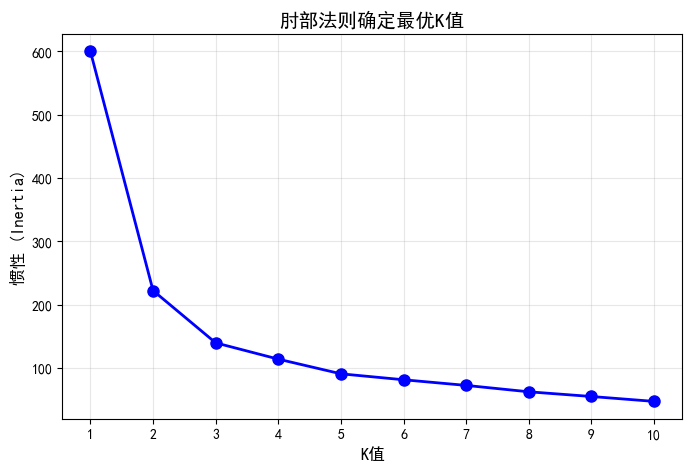

In [19]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K值', fontsize=12)
plt.ylabel('惯性 (Inertia)', fontsize=12)
plt.title('肘部法则确定最优K值', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [21]:
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
print(f"调整兰德指数 (ARI): {ari:.4f}")
print(f"归一化互信息 (NMI): {nmi:.4f}")
print(f"聚类中心：")
print(kmeans.cluster_centers_)

调整兰德指数 (ARI): 0.6201
归一化互信息 (NMI): 0.6595
聚类中心：
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


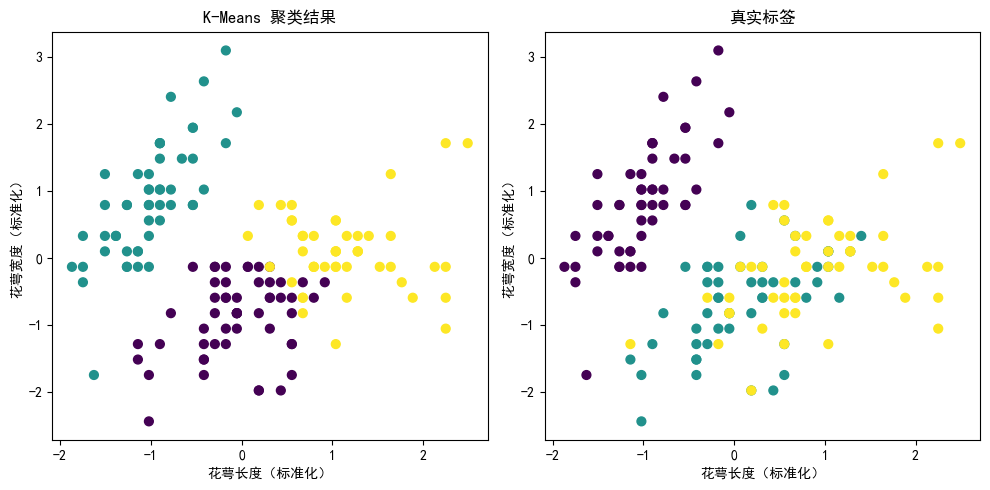

In [24]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis', s=40)
plt.xlabel('花萼长度（标准化）')
plt.ylabel('花萼宽度（标准化）')
plt.title('K-Means 聚类结果')
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='viridis', s=40)
plt.xlabel('花萼长度（标准化）')
plt.ylabel('花萼宽度（标准化）')
plt.title('真实标签')
plt.tight_layout()
plt.show()